In [127]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## Data


In [129]:
data = pd.read_csv('./../data/earthquake_alert_balanced_dataset.csv')

## Basic Statistics


In [130]:
data.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [132]:
data.describe().round(2)

,magnitude,depth,cdi,mmi,sig
count,1300.00,1300.00,1300.00,1300.00,1300.00
mean,7.06,50.32,6.98,6.94,-9.75
std,0.42,104.35,2.24,1.35,62.25
min,6.50,2.00,0.00,1.00,-128.00
25%,6.70,12.00,6.00,6.00,-54.00
50%,7.00,19.00,8.00,7.00,-7.00
75%,7.30,38.00,8.00,8.00,31.00
max,8.60,670.00,9.00,9.00,127.00


In [133]:
order = ['green', 'yellow', 'orange', 'red']

for col in data.select_dtypes(include=['int', 'float']).columns:
    print(col)
    display(data.groupby('alert')[col].describe().round(2).reindex(order))

magnitude


,count,mean,std,min,25%,50%,75%,max
alert,,,,,,,,
green,325.0,6.86,0.37,6.5,6.60,6.80,7.00,8.3
yellow,325.0,7.08,0.47,6.5,6.70,6.98,7.43,8.6
orange,325.0,7.06,0.39,6.5,6.78,6.96,7.25,8.3
red,325.0,7.25,0.36,6.6,7.04,7.22,7.51,8.2


depth


,count,mean,std,min,25%,50%,75%,max
alert,,,,,,,,
green,325.0,114.55,187.16,2.0,13.0,27.0,107.0,670.0
yellow,325.0,41.06,41.86,5.0,14.0,22.0,44.0,146.0
orange,325.0,29.78,30.78,10.0,13.0,19.0,37.0,231.0
red,325.0,15.90,9.46,8.0,9.0,13.0,19.0,47.0


cdi


,count,mean,std,min,25%,50%,75%,max
alert,,,,,,,,
green,325.0,4.37,2.87,0.0,2.0,5.0,7.0,9.0
yellow,325.0,7.34,1.20,3.0,7.0,8.0,8.0,9.0
orange,325.0,8.05,0.60,7.0,8.0,8.0,8.0,9.0
red,325.0,8.14,0.83,5.0,8.0,8.0,9.0,9.0


mmi


,count,mean,std,min,25%,50%,75%,max
alert,,,,,,,,
green,325.0,5.24,1.39,1.0,4.0,5.0,6.0,8.0
yellow,325.0,6.92,0.64,6.0,7.0,7.0,7.0,9.0
orange,325.0,7.57,0.55,7.0,7.0,8.0,8.0,9.0
red,325.0,8.03,0.47,7.0,8.0,8.0,8.0,9.0


sig


,count,mean,std,min,25%,50%,75%,max
alert,,,,,,,,
green,325.0,-40.46,64.36,-128.0,-96.0,-53.0,-5.0,127.0
yellow,325.0,-22.62,72.20,-128.0,-81.0,-34.0,32.0,121.0
orange,325.0,2.46,47.19,-117.0,-21.0,-1.0,51.0,98.0
red,325.0,21.62,41.26,-56.0,-8.0,24.0,38.0,94.0


## Data visualization


In [134]:
palette = ['#8de5a1', '#fffea3', '#ffb482', '#ff9f9b']
hue_order = ['green', 'yellow', 'orange', 'red']

### Countplot


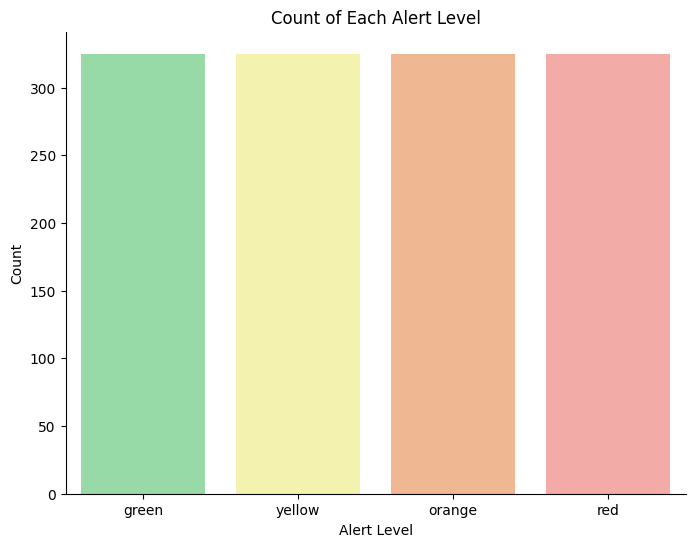

In [135]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x='alert',
    data=data,
    palette=palette,
    hue='alert',
    hue_order=hue_order,
)
sns.despine()
plt.title('Count of Each Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Count')
plt.show()

### Histrogram


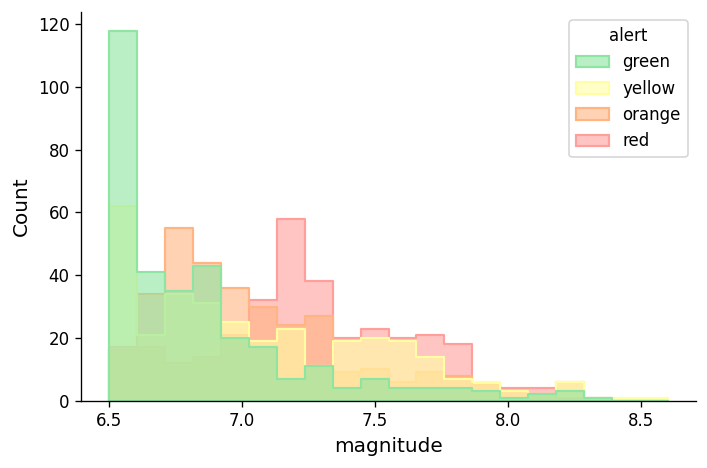

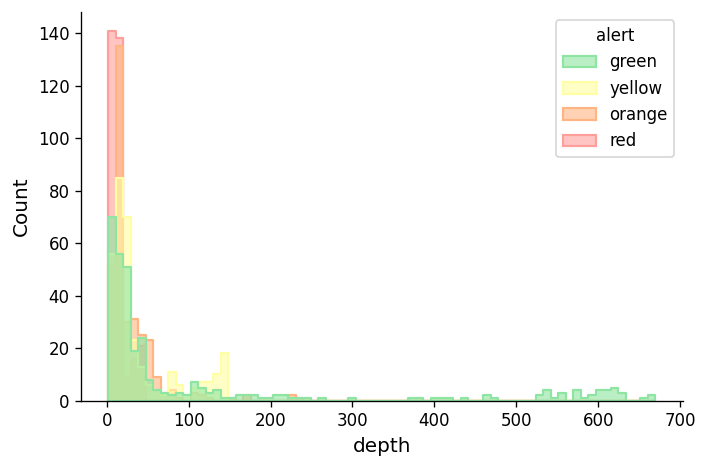

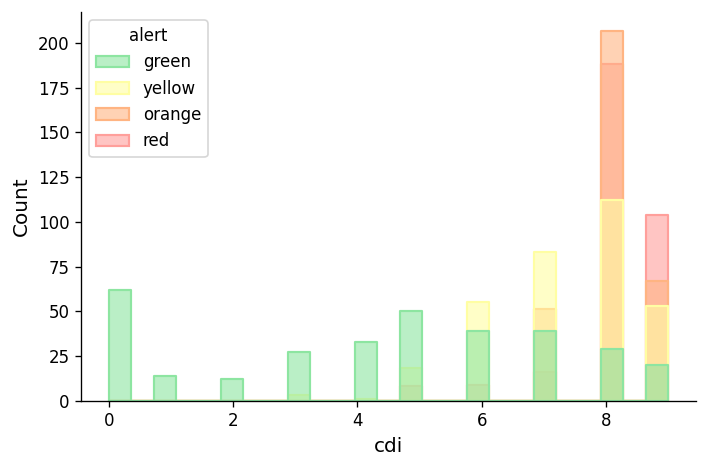

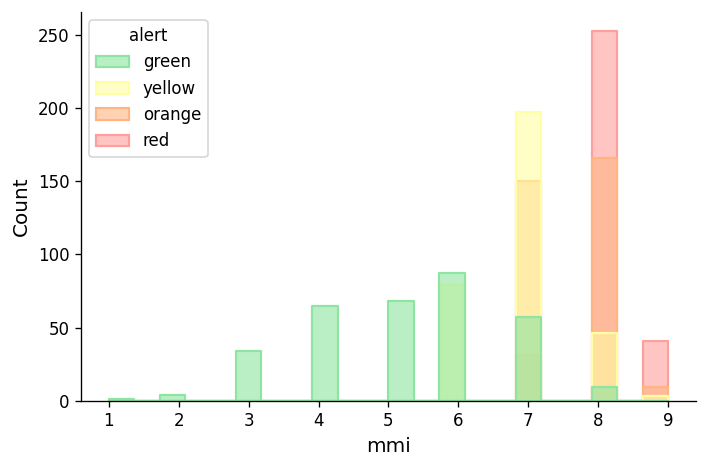

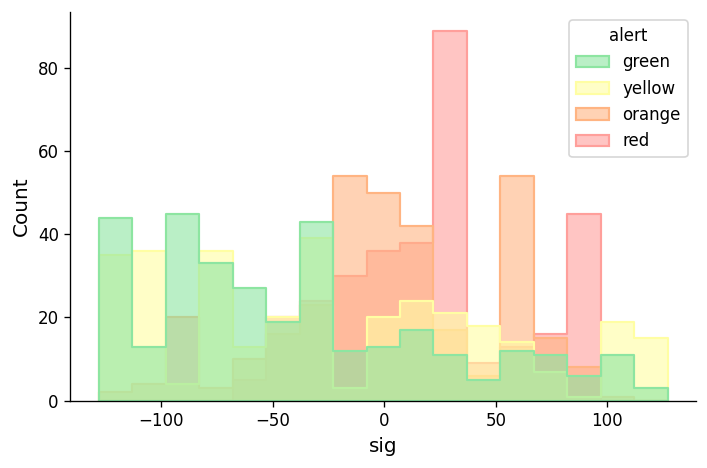

In [136]:
for feature in data.columns[:-1]:
    plt.figure(figsize=(6, 4), dpi=120)
    ax = sns.histplot(
        data=data,
        x=feature,
        hue=data.columns[-1],
        # fill=True,
        alpha=0.6,
        element='step',
        linewidth=1.3,
        # line_kws={"alpha": 0.7, "linewidth": 1.3},
        common_norm=False,
        palette=palette,
        legend=True,
        hue_order=hue_order,
        # kde=True,
    )
    plt.xlabel(feature, fontdict={'fontsize': 12})
    plt.ylabel('Count', fontdict={'fontsize': 12})
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    # plt.title(f"")
    # plt.legend(title="alert", labels=[])
    sns.despine()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

### Boxplot


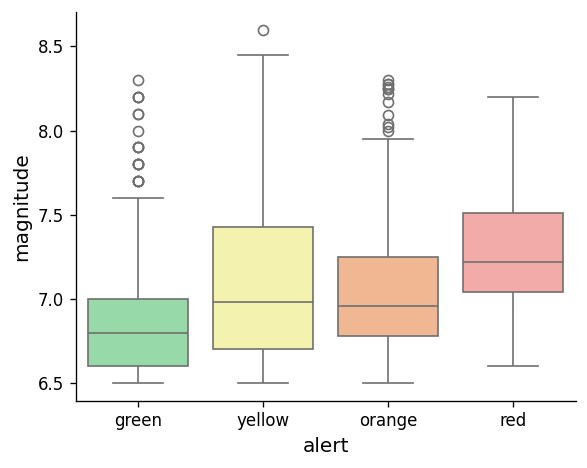

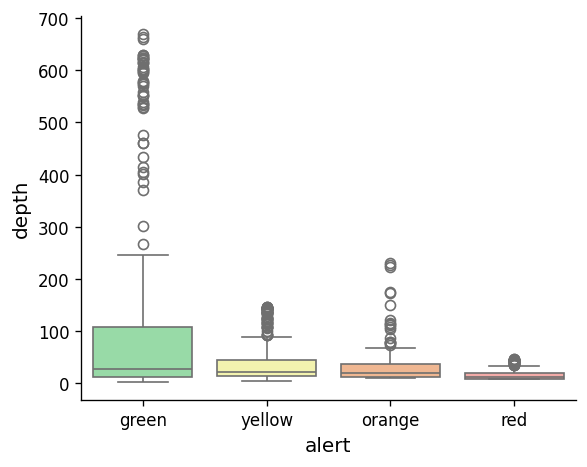

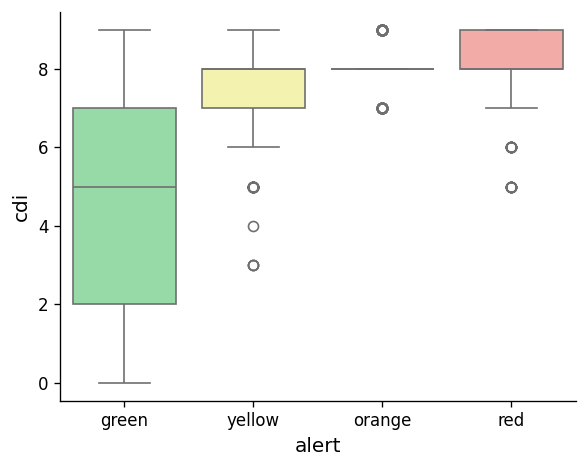

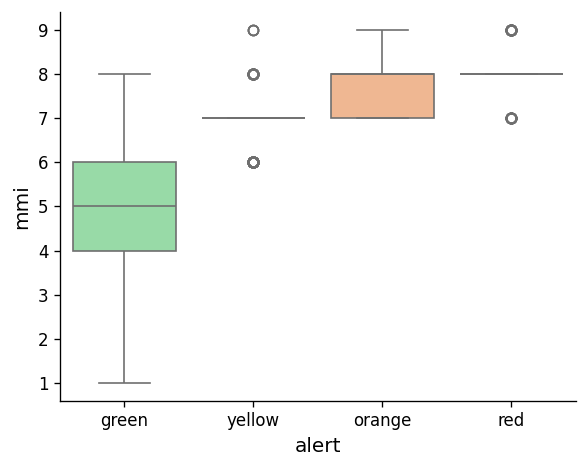

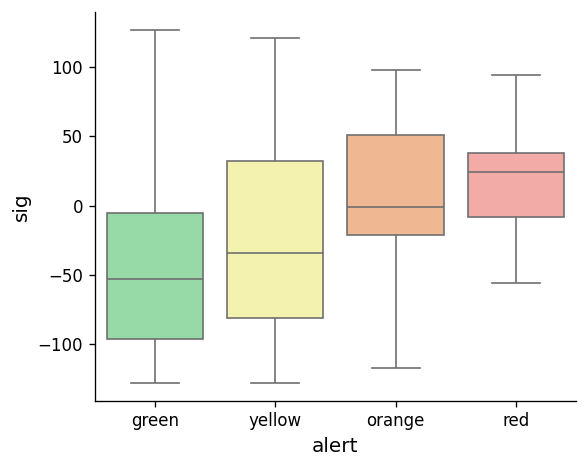

In [137]:
for feature in data.columns[:-1]:
    plt.figure(figsize=(5, 4), dpi=120)
    sns.boxplot(
        data=data,
        x=data.columns[-1],
        y=feature,
        # palette="pastel",
        palette=palette,
        hue=data.columns[-1],
        hue_order=hue_order,
        # legend=True
    )
    plt.xlabel(feature, fontdict={'fontsize': 12})
    plt.ylabel('Count', fontdict={'fontsize': 12})
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel(data.columns[-1])
    plt.ylabel(feature)
    # plt.title(f"")
    sns.despine()
    plt.tight_layout()
    plt.show()

### Scatterplot


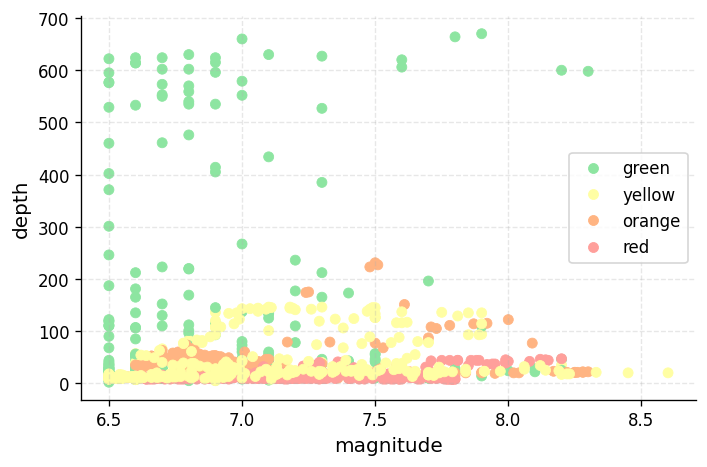

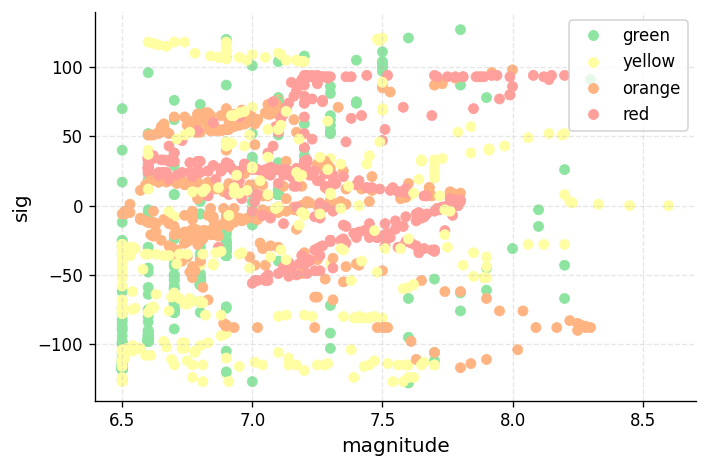

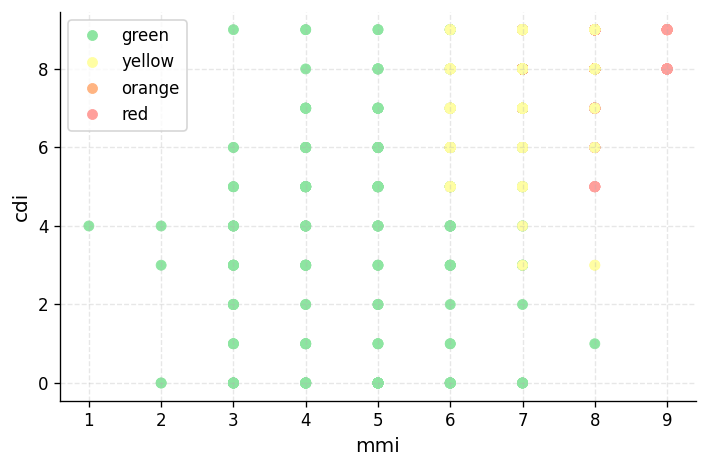

In [138]:
comparison_pairs = [
    ('magnitude', 'depth'),
    ('magnitude', 'sig'),
    ('mmi', 'cdi'),
]
markers = {'green': 'o', 'yellow': 'o', 'orange': 'o', 'red': 'o'}

for x_feature, y_feature in comparison_pairs:
    plt.figure(figsize=(6, 4), dpi=120)
    g = sns.scatterplot(
        data=data,
        x=x_feature,
        y=y_feature,
        hue='alert',
        # markers=markers,
        # s=36,
        palette=palette,
        hue_order=hue_order,
        # alpha=0.7,
        edgecolor=None,
    )

    plt.xlabel(x_feature, fontdict={'fontsize': 12})
    plt.ylabel(y_feature, fontdict={'fontsize': 12})
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    sns.despine()
    plt.grid(
        True,
        linestyle='--',
        alpha=0.3,
    )
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

### Pairplot

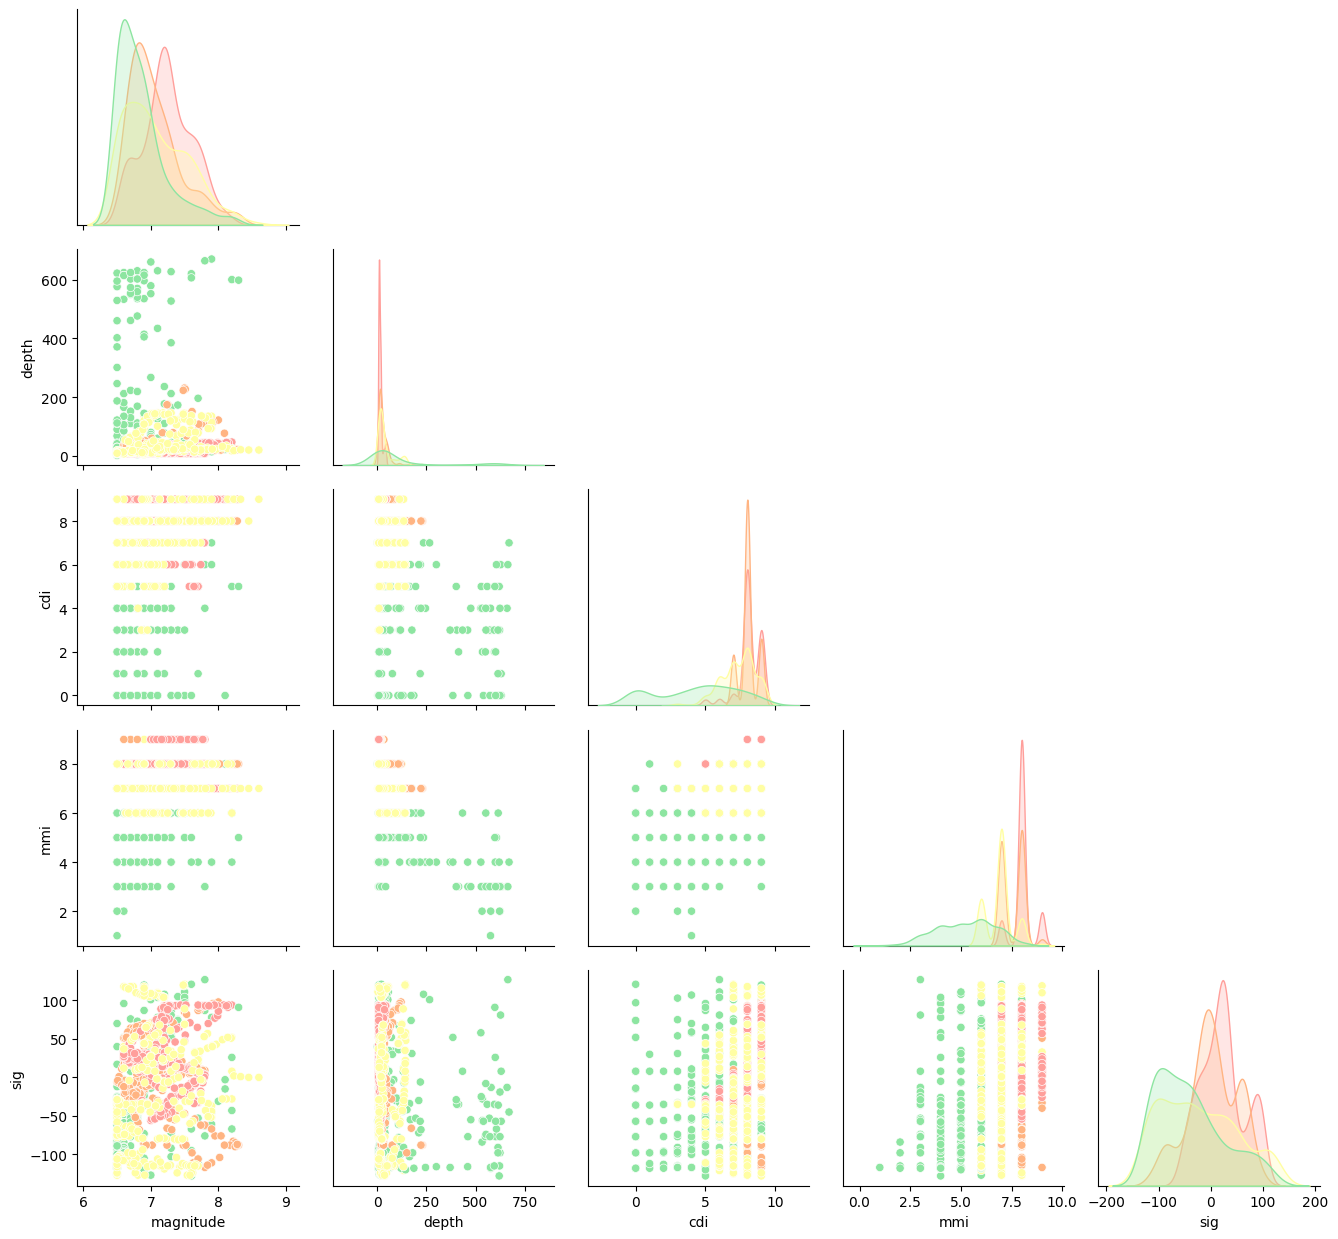

In [139]:
g = sns.pairplot(
    data,
    hue=data.columns[-1],
    palette=palette,
    diag_kind="kde",
    hue_order=hue_order,
    corner=True,
)

g.figure.subplots_adjust(right=0.85)

if hasattr(g, "_legend") and g._legend is not None:
    g._legend.remove()

for row in g.axes:
    for ax in row:
        if ax is None:
            continue
        ax.grid(False)
        ax.set_xlabel(ax.get_xlabel(), fontsize=10)
        ax.set_ylabel(ax.get_ylabel(), fontsize=10)

n = g.axes.shape[0]
for r in range(n):
    for c in range(1, n):
        ax = g.axes[r, c]
        if ax is not None:
            ax.tick_params(left=False, labelleft=False)
            ax.spines["left"].set_visible(False)

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

### Correlation Matrix


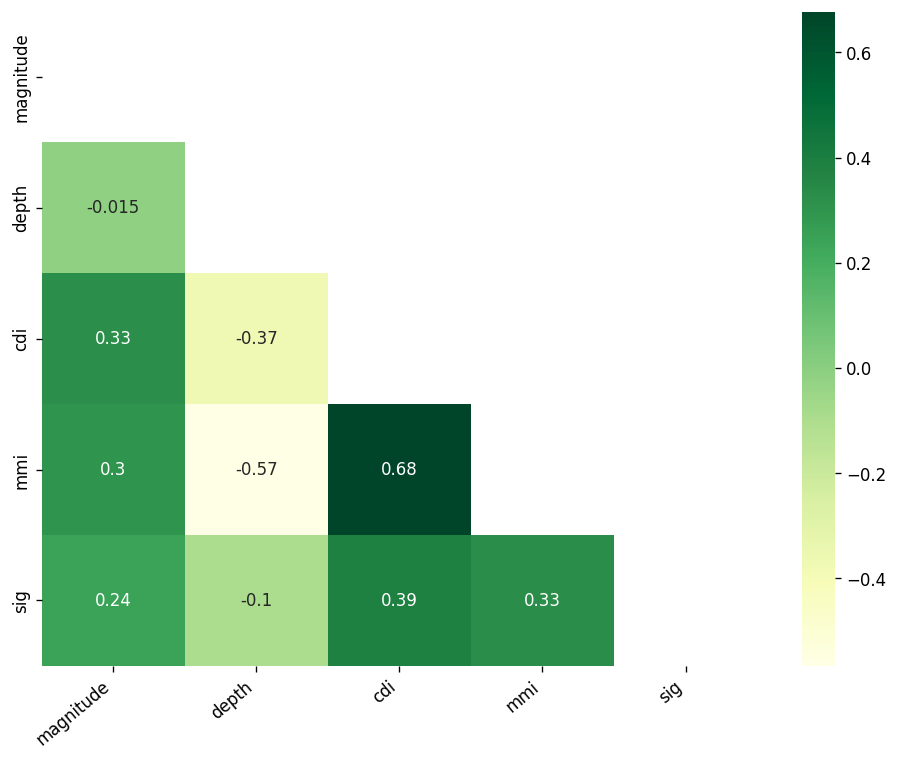

In [140]:
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(8, 6), dpi=120)
g = sns.heatmap(
    corr,
    annot=True,
    cmap='YlGn',
    mask=mask,
)

plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=40, ha='right')
plt.yticks()

plt.show()